In [53]:
import os, re, json
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from bs4 import BeautifulSoup
import re

In [54]:

def extract_case_metadata(raw_html):
    """Extract Decision Date, Case No, Bench, Verdict, Judges, and Parties"""
    if not raw_html:
        return None, None, None, None, None, [], None, None

    soup = BeautifulSoup(raw_html, "html.parser")
    text = soup.get_text(" ", strip=True)

    # --- Main details ---
    decision_date = re.search(r"Decision\s*Date\s*[:\-]?\s*([0-9]{1,2}[-/][0-9]{1,2}[-/][0-9]{2,4})", text)
    case_no = re.search(r"Case\s*No\s*[:\-]?\s*([A-Z\s.()0-9/,-]+)", text)
    disposal_nature = re.search(r"Disposal\s*(?:Nature)?\s*[:\-]?\s*([A-Za-z\s&()]+)", text)
    bench_info = re.search(r"Bench\s*[:\-]?\s*([A-Za-z0-9\s]+)", text)
    direction_issue = re.search(r"Direction\s*Issue\s*[:\-]?\s*([A-Za-z\s&()]+)", text)

    decision_date = decision_date.group(1).strip() if decision_date else None
    case_no = case_no.group(1).strip() if case_no else None
    disposal_nature = disposal_nature.group(1).strip() if disposal_nature else None
    bench_info = bench_info.group(1).strip() if bench_info else None
    direction_issue = direction_issue.group(1).strip() if direction_issue else None

    # --- Verdict inference ---
    verdict_label = None
    if disposal_nature:
        if re.search(r"allow|grant|upheld|accepted|partly allow|partly allowed|disposed off|quash", disposal_nature, re.I):
            verdict_label = 1.0
        elif re.search(r"dismiss|refuse|reject|disallow", disposal_nature, re.I):
            verdict_label = 0.0
    elif direction_issue:
        if re.search(r"allow|partly", direction_issue, re.I):
            verdict_label = 1.0
        elif re.search(r"dismiss|refuse", direction_issue, re.I):
            verdict_label = 0.0

    # --- Judges (Coram) ---
    coram_match = re.search(r"Coram\s*[:\-]?\s*([^<]+)", raw_html, flags=re.I)
    judges = []
    if coram_match:
        raw_judge = re.sub(r"<[^>]+>", "", coram_match.group(1))
        raw_judge = re.sub(r"\s+", " ", raw_judge)
        judges = [j.strip() for j in re.split(r",|&|and", raw_judge) if j.strip()]
    bench_size = len(judges) if judges else (int(re.search(r"(\d+)", str(bench_info)).group(1)) if bench_info else 1)

    # --- Parties ---
    party_match = re.search(r"<strong>(.*?)<span.*?versus.*?</span>(.*?)</strong>", raw_html, flags=re.I)
    petitioner = party_match.group(1).strip() if party_match else None
    respondent = party_match.group(2).strip() if party_match else None

    return (
        decision_date,
        case_no,
        bench_info,
        disposal_nature,
        verdict_label,
        judges,
        petitioner,
        respondent,
    )

In [55]:
# =======================================
# 1️⃣ Folder structure
# =======================================
base_json_dir = os.path.join("My_Datasets", "SC_2020-2025")
text_dir = "Extracted_Texts"

# Dynamically detect all metadata folders under each year
year_folders = []
for year in range(2020, 2026):
    metadata_path = os.path.join(base_json_dir, str(year), "metadata")
    if os.path.exists(metadata_path):
        year_folders.append(metadata_path)

print("Detected metadata folders:")
for folder in year_folders:
    print(" →", folder)

# Collect all JSON files
json_files = []
for year_dir in year_folders:
    for f in os.listdir(year_dir):
        if f.endswith(".json"):
            json_files.append(os.path.join(year_dir, f))

print(f"\n✅ Found {len(json_files)} metadata files across {len(year_folders)} year folders.")

Detected metadata folders:
 → My_Datasets\SC_2020-2025\2020\metadata
 → My_Datasets\SC_2020-2025\2021\metadata
 → My_Datasets\SC_2020-2025\2022\metadata
 → My_Datasets\SC_2020-2025\2023\metadata
 → My_Datasets\SC_2020-2025\2024\metadata
 → My_Datasets\SC_2020-2025\2025\metadata

✅ Found 4370 metadata files across 6 year folders.


In [56]:
# =======================================
# 2️⃣ Load + Merge JSON ↔ Text
# =======================================
records = []

for jfile in tqdm(json_files):
    base = os.path.splitext(os.path.basename(jfile))[0]
    text_path = os.path.join(text_dir, base + "_EN.txt")

    if not os.path.exists(text_path):
        continue  # skip missing

    try:
        with open(jfile, "r", encoding="utf-8") as jf:
            meta = json.load(jf)
        with open(text_path, "r", encoding="utf-8") as tf:
            text = tf.read()

        raw_html = meta.get("raw_html", "")
        year = meta.get("citation_year")

        # --- Extract structured metadata using the universal parser ---
        (
            decision_date,
            case_no,
            bench_info,
            disposal_nature,
            verdict_label,
            judges,
            petitioner,
            respondent
        ) = extract_case_metadata(raw_html)

        # --- Compute bench size safely ---
        bench_size = len(judges) if judges else (int(re.search(r"(\d+)", str(bench_info)).group(1)) if bench_info and re.search(r"\d+", bench_info) else 1)

        record = {
            "case_id": meta.get("path", base),
            "year": int(year) if year else None,
            "decision_date": decision_date,
            "case_no": case_no,
            "bench_info": bench_info,
            "bench_size": bench_size,
            "judges": judges,
            "petitioner": petitioner,
            "respondent": respondent,
            "disposal_nature": disposal_nature,
            "verdict_label": verdict_label,
            "raw_html": raw_html,
            "text": text
        }

        records.append(record)

    except Exception as e:
        print(f"⚠️ Error reading {jfile}: {e}")

df = pd.DataFrame(records)
print("✅ Records loaded:", len(df))
print("Columns:", df.columns.tolist())


 67%|██████▋   | 2920/4370 [00:08<00:04, 314.60it/s]

⚠️ Error reading My_Datasets\SC_2020-2025\2023\metadata\2023_3_644_648.json: 'NoneType' object has no attribute 'group'


100%|██████████| 4370/4370 [00:12<00:00, 357.77it/s]


✅ Records loaded: 4367
Columns: ['case_id', 'year', 'decision_date', 'case_no', 'bench_info', 'bench_size', 'judges', 'petitioner', 'respondent', 'disposal_nature', 'verdict_label', 'raw_html', 'text']


In [57]:
# =======================================
# 3️⃣ Feature Enrichment
# =======================================
df = df.dropna(subset=["text"])
df["year"] = pd.to_numeric(df.get("year", 0)).fillna(0).astype(int)
df["decade"] = (df["year"] // 10) * 10

# ---- Structural ----
df["num_words_text"] = df["text"].apply(lambda x: len(str(x).split()))
df["num_lines"] = df["text"].apply(lambda x: len(str(x).splitlines()))

# ---- Legal Signals ----
def extract_act_names(text):
    return re.findall(r'([A-Z][A-Za-z\s]+Act[, ]\s*\d{4})', str(text))

def extract_sections(text):
    return re.findall(r's\.?\s*\d+[A-Za-z]*', str(text))

def extract_ipc_mentions(text):
    return re.findall(r'(?:Section|s\.?)\s*\d+\s*(?:of\s+the\s+IPC|Indian Penal Code)', str(text), flags=re.I)

df["act_names"] = df["text"].apply(extract_act_names)
df["sections"] = df["text"].apply(extract_sections)
df["ipc_mentions"] = df["text"].apply(extract_ipc_mentions)
df["num_unique_acts"] = df["act_names"].apply(lambda x: len(set(x)))
df["num_ipc_refs"] = df["ipc_mentions"].apply(len)
df["has_ipc"] = (df["num_ipc_refs"] > 0).astype(int)

In [58]:
# ---- Sentiment + Context ----
pos_words = ["granted", "allowed", "favour", "upheld", "entitled"]
neg_words = ["dismissed", "rejected", "refused", "denied", "not maintainable"]
df["sentiment_score"] = df["text"].apply(lambda t: sum(w in t.lower() for w in pos_words) - sum(w in t.lower() for w in neg_words))
df["petitioner_mentions"] = df["text"].str.count(r"(?i)petitioner")
df["respondent_mentions"] = df["text"].str.count(r"(?i)respondent")
df["pet_vs_resp_ratio"] = df.apply(lambda r: (r["petitioner_mentions"] + 1)/(r["respondent_mentions"] + 1), axis=1)


In [59]:
# ---- Keyword extraction ----
def extract_keywords(text, top_n=10):
    words = re.findall(r'\b[a-zA-Z]{4,}\b', str(text).lower())
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    common = [w for w, _ in Counter(words).most_common(top_n)]
    return common

df["keywords"] = df["text"].apply(lambda x: extract_keywords(x, 10))


In [60]:
# ---- Case type inference ----
def infer_case_type(text):
    t = str(text).lower()
    if "criminal" in t: return "Criminal"
    if "civil" in t: return "Civil"
    if "tax" in t or "income tax" in t: return "Tax"
    if "constitution" in t: return "Constitutional"
    if "labour" in t or "industrial" in t: return "Labour"
    return "Other"

df["case_type"] = df["text"].apply(infer_case_type)


In [61]:
# ---- Citations ----
def extract_citations(text):
    return re.findall(r'\(\d{4}\)\s*\d+\s*SCC\s*\d+|AIR\s*\d{4}\s*SC\s*\d+|\[\d{4}\]\s*\d+\s*SCR\s*\d+', str(text))

df["citations"] = df["text"].apply(extract_citations)
df["num_citations"] = df["citations"].apply(len)


In [62]:
# ---- Constitution Articles ----
def extract_constitution_articles(text):
    return re.findall(r'Article\s*\d+[A-Za-z0-9]*', str(text), flags=re.I)

df["constitution_articles"] = df["text"].apply(extract_constitution_articles)
df["has_constitution_article"] = df["constitution_articles"].apply(lambda x: 1 if len(x) > 0 else 0)


In [63]:
# =======================================
# 🔍 Enhanced IPC Reference Detection
# =======================================

def extract_additional_ipc_mentions(text):
    if not isinstance(text, str):
        return []
    # Broader patterns: "Section 302", "s.420", "Sec. 376 IPC", "under Section 498A"
    patterns = [
        r"(?:Section|Sec\.?|s\.?)\s*\d+[A-Za-z]*\s*(?:IPC|I\.P\.C\.|Indian Penal Code)?",
        r"u/s\s*\d+[A-Za-z]*"  # covers shorthand like "u/s 420"
    ]
    combined_pattern = "|".join(patterns)
    return re.findall(combined_pattern, text, flags=re.I)

# Apply detection
df["ipc_mentions_extra"] = df["text"].apply(extract_additional_ipc_mentions)

# Merge both detections (old + new)
df["total_ipc_mentions"] = (
    df["ipc_mentions"].apply(len) + df["ipc_mentions_extra"].apply(len)
)
df["has_ipc"] = (df["total_ipc_mentions"] > 0).astype(int)

# Show coverage stats
total_cases = len(df)
cases_with_ipc = df["has_ipc"].sum()
print(f"✅ Enhanced IPC detection complete: {cases_with_ipc}/{total_cases} cases ({cases_with_ipc/total_cases*100:.2f}%) now have IPC references.")


✅ Enhanced IPC detection complete: 4351/4367 cases (99.63%) now have IPC references.


In [64]:
# =======================================
# 4️⃣ Save enriched parquet
# =======================================
out_path = "SupremeCourt_Combined_2020_2025_enriched.parquet"
df.to_parquet(out_path, index=False)
print(f"✅ Enriched dataset saved: {out_path} — shape: {df.shape}")

✅ Enriched dataset saved: SupremeCourt_Combined_2020_2025_enriched.parquet — shape: (4367, 34)


Dataset Quality Visualizer

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# =======================================
# 1️⃣ Load dataset
# =======================================
df = pd.read_parquet("SupremeCourt_Combined_2020_2025_enriched.parquet")
print(f"✅ Loaded {len(df)} records with {df.shape[1]} columns")


✅ Loaded 4367 records with 34 columns



--- Missing Values (Top 15) ---
verdict_label      7.01
disposal_nature    3.30
year               0.00
case_id            0.00
bench_info         0.00
decision_date      0.00
bench_size         0.00
judges             0.00
petitioner         0.00
case_no            0.00
respondent         0.00
raw_html           0.00
text               0.00
decade             0.00
num_words_text     0.00
dtype: float64


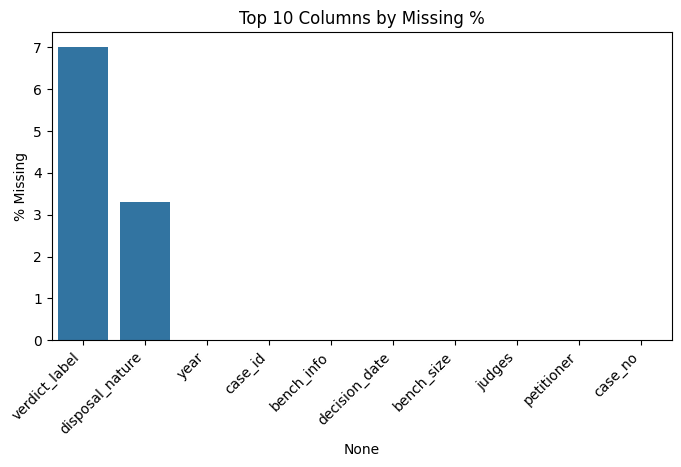

In [67]:
# =======================================
# 2️⃣ Missing value audit
# =======================================
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Verdict Label Distribution ---
verdict_label
1.0    3055
0.0    1006
NaN     306
Name: count, dtype: int64


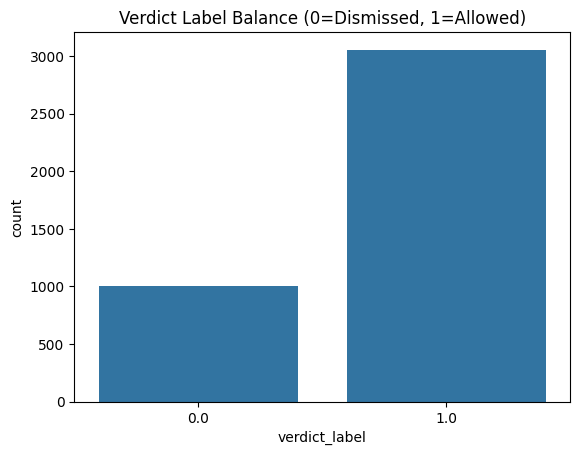

In [68]:
# =======================================
# 3️⃣ Data completeness & label balance
# =======================================
print("\n--- Verdict Label Distribution ---")
print(df['verdict_label'].value_counts(dropna=False))
sns.countplot(x='verdict_label', data=df)
plt.title("Verdict Label Balance (0=Dismissed, 1=Allowed)")
plt.show()


--- Text Length Stats ---
count      4367.00
mean       8648.86
std       11493.52
min         183.00
25%        3321.50
50%        5457.00
75%        9406.00
max      150429.00
Name: text_len, dtype: float64


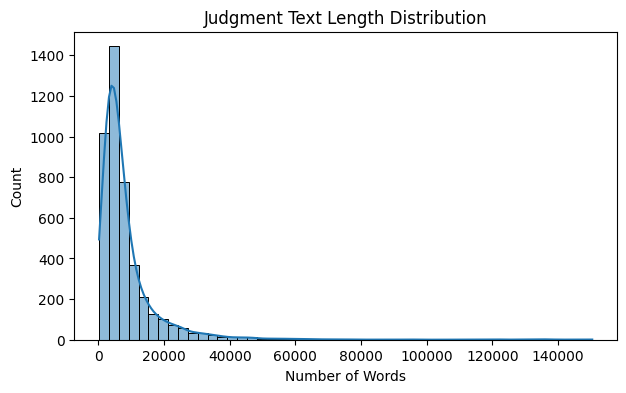

In [69]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Judgment Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [70]:
# =======================================
# 5️⃣ Feature richness audit
# =======================================
print("\n--- Bench & Case Type ---")
print("Average bench size:", round(df['bench_size'].mean(), 2))
print("\nCase type distribution:\n", df['case_type'].value_counts(normalize=True).mul(100).round(1))

print("\nHas IPC references:", df['has_ipc'].sum(), "/", len(df))
print("Has Constitution Articles:", df['has_constitution_article'].sum(), "/", len(df))



--- Bench & Case Type ---
Average bench size: 1.14

Case type distribution:
 case_type
Civil             58.4
Criminal          41.5
Other              0.1
Constitutional     0.0
Tax                0.0
Name: proportion, dtype: float64

Has IPC references: 4351 / 4367
Has Constitution Articles: 2139 / 4367


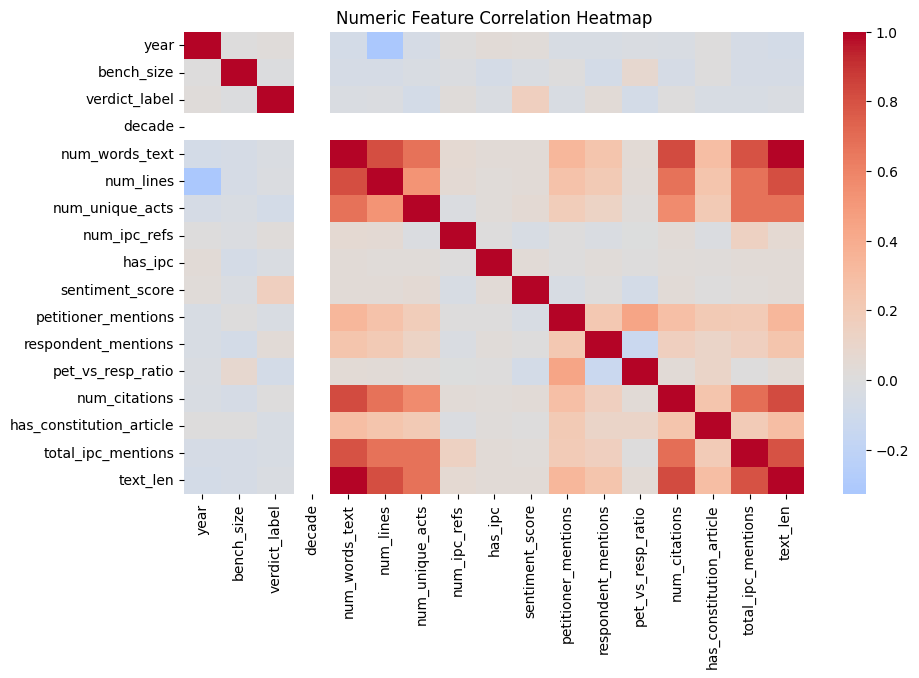

In [71]:
# =======================================
# 6️⃣ Correlation between numeric features
# =======================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

In [72]:
# =======================================
# 7️⃣ Quick semantic sanity: top frequent Acts & Articles
# =======================================
acts = df['act_names'].explode().dropna().value_counts().head(10)
articles = df['constitution_articles'].explode().dropna().value_counts().head(10)

print("\n--- Top 10 Most Frequent Acts ---\n", acts)
print("\n--- Top 10 Constitution Articles ---\n", articles)


--- Top 10 Most Frequent Acts ---
 act_names
Arbitration and Conciliation Act, 1996    655
Limitation Act, 1963                      598
Evidence Act, 1872                        511
Land Acquisition Act, 1894                441
Companies Act, 2013                       436
Arbitration Act, 1996                     390
Companies Act, 1956                       380
Income Tax Act, 1961                      334
Consumer Protection Act, 1986             294
Transfer of Property Act, 1882            292
Name: count, dtype: int64

--- Top 10 Constitution Articles ---
 constitution_articles
Article 14     2592
Article 226    2349
Article 21     1779
Article 19     1583
Article 16     1530
Article 142    1340
Article 32     1288
Article 30     1044
Article 136     941
Article 370     910
Name: count, dtype: int64
